# Apricot CKN

# Setup

## Library import
We import all the required Python libraries

In [1]:
import sys, re, pickle
from pathlib import Path
from datetime import datetime
from IPython.display import Markdown, display
from collections import defaultdict

import pandas as pd
import networkx as nx

In [2]:
# vis
import matplotlib.pyplot as plt
import seaborn as sns

Import functions from the skm-tools package. 

In [3]:
from skm_tools import load_networks, ckn_utils

from skm_tools.translate import load_translation_file, integrate_translation_ckn

In [4]:
today = datetime.today().strftime('%Y.%m.%d'); today

'2026.04.26'

In [5]:
base_dir = Path("./")
data_dir = base_dir / "data"
output_dir = base_dir / "fruitdiv-output"

genotypying_dir = Path("/run/user/1000/gvfs/smb-share:server=srvljfs.nib.sql,share=fito/DEJAVNOSTI/OMIKE/pISA-Projects/_p_ExtAnalysis/_I_FruitDiv/_S_02_Omics_Integration/_A_02_ArmeniacaGenotyping-dry-tmp/")

In [6]:
species_code = "parm"
species = "apricot"
translation_df = load_translation_file(species_code, data_dir / "translation_ath_to_{species}.tsv.gz")

In [7]:
translation_df

,ath_source,apricot,symbol_source,filter_criteria,evidence
0,AT1G01020,PruarM.2G365300,ARV1,MCScanX,"FastOMA,MCScanX,OrthoDB,MapMan4_Match"
1,AT1G01030,PruarM.2G365200,NGA3,MCScanX,"FastOMA,MCScanX,OrthoDB,MapMan4_Match"
2,AT1G01030,PruarM.5G193300,NGA3,OrthoDB_FastOMA_RBH_MapMan4,"FastOMA,OrthoDB,RBH,MapMan4_Match"
3,AT1G01040,PruarM.2G365100,DCL1,MCScanX,"FastOMA,MCScanX,OrthoDB,RBH,MapMan4_Match"
4,AT1G01050,PruarM.2G364900,PPa1,MCScanX,"FastOMA,MCScanX,OrthoDB,MapMan4_Match"
...,...,...,...,...,...
24276,AT5G67590,PruarM.6G333400,FRO1,MCScanX,"FastOMA,MCScanX,OrthoDB,RBH,MapMan4_Match"
24277,AT5G67610,PruarM.6G332900,NaN,MCScanX,"FastOMA,MCScanX,OrthoDB,RBH,MapMan4_Match"
24278,AT5G67620,PruarM.6G332800,NaN,MCScanX,"FastOMA,MCScanX,OrthoDB,RBH,MapMan4_Match"
24279,AT5G67630,PruarM.1G753600,NaN,OrthoDB_FastOMA_RBH_MapMan4,"FastOMA,OrthoDB,RBH,MapMan4_Match"


In [8]:
g_source_attribute='TAIR'
t_source_col='ath_source'
t_target_col=species

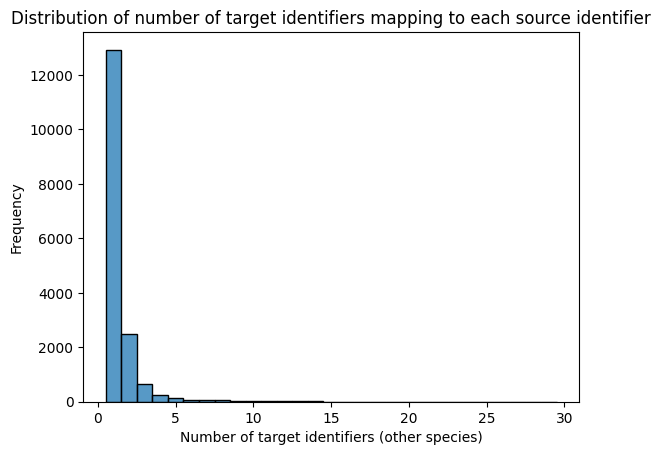

In [9]:
sns.histplot(
    translation_df.groupby(t_source_col)[t_target_col].apply(len),
    discrete=True,
    stat="frequency",
)
plt.title('Distribution of number of target identifiers mapping to each source identifier')
plt.xlabel('Number of target identifiers (other species)')
plt.ylabel('Frequency')
plt.show()

In [10]:
mapping = translation_df.groupby(t_source_col)[t_target_col].apply(list).to_dict()    

## Load CKN

In [11]:
ckn_edge_path = data_dir / "AtCKN-v2-2023.06.tsv.gz" 
ckn_node_path = data_dir / "AtCKN-v2-2023.06_node-annot.tsv.gz"

In [12]:
ckn = load_networks.ckn_to_networkx(
    edge_path=ckn_edge_path, 
    node_path=ckn_node_path
)

print(f"\nNumber of nodes: {ckn.number_of_nodes()}\nNumber of edges: {ckn.number_of_edges()}")


Number of nodes: 26234
Number of edges: 898887


In [13]:
keep_edge_ranks=[0, 1, 2]
ckn_utils.filter_ckn_edges(ckn, keep_edge_ranks=keep_edge_ranks, remove_isolates=True)
_ = ckn_utils.rank_counts(ckn)

Removed 791858 edges from network.
rank 0:	 2,837
rank 1:	 36,620
rank 2:	 67,572
rank 3:	 0
rank 4:	 0


In [14]:
set([data['node_type'] for n, data in ckn.nodes(data=True)])

{'abiotic',
 'antisense_long_noncoding_rna',
 'biotic',
 'complex',
 'metabolite',
 'mirna',
 'other_rna',
 'pre_trna',
 'process',
 'protein_coding',
 'pseudogene',
 'small_nucleolar_rna',
 'transposable_element_gene'}

## Translation

In [15]:
ckn_apricot = integrate_translation_ckn(
    ckn,
    translation_df,
    g_source_attribute='TAIR',
    t_source_col='ath_source',
    t_target_col='apricot',
    method='full_replacement',
    edges_within_translation=True,
    edges_across_translation=True,
    keep_unmapped=True
)

In [16]:
ckn.number_of_nodes(), ckn.number_of_edges()

(13513, 107029)

In [17]:
ckn_apricot.number_of_nodes(), ckn_apricot.number_of_edges()

(17882, 199406)

In [18]:
# write out ids for selecting genes from other data types
with open(output_dir / "ckn_apricot_node_translations.tsv", "w") as f:
    f.write(f"node_id\tath_id\t{species_code}_id\n")
    for node, data in ckn_apricot.nodes(data=True):
            if "translation" in data and data['translation']:
                f.write(f"{node}\t{data['translated_from']}\t{data['translation']}\n")

## Mercator

In [19]:
df_mercator = pd.read_excel(
    f"../../skm-translate/output/{species}-ath_orthologues-kept_2025-09-24-strict.xlsx",
    usecols=["from_geneID", "to_geneID", "plant_BINCODE", "plant_NAME", "plant_DESCRIPTION"]
)
df_mercator.head()

,from_geneID,to_geneID,plant_BINCODE,plant_NAME,plant_DESCRIPTION
0,AT1G01020,PruarM.2G365300,35.2,not assigned.not annotated,mercator4v7.0: not classified & original descr...
1,AT1G01030,PruarM.2G365200,14.5.9.3,RNA biosynthesis.DNA-binding transcriptional r...,mercator4v7.0: RAV-NGATHA transcription factor...
2,AT1G01030,PruarM.5G193300,14.5.9.3,RNA biosynthesis.DNA-binding transcriptional r...,mercator4v7.0: RAV-NGATHA transcription factor...
3,AT1G01040,PruarM.2G365100,16.5.1.1.1.1.1,RNA homeostasis.mRNA silencing.miRNA pathway.m...,mercator4v7.0: endoribonuclease component *(DC...
4,AT1G01050,PruarM.2G364900,27.7.1,Multi-process regulation.pyrophosphate homeost...,mercator4v7.0: cytosolic pyrophosphatase & ori...


In [20]:
df_mercator.index = df_mercator[["from_geneID", "to_geneID"]].agg("_".join, axis=1)
df_mercator.drop(["from_geneID", "to_geneID"], axis=1, inplace=True)
df_mercator.columns = [f"{species}_MapMan_BINCODE", f"{species}_MapMan_NAME", f"{species}_MapMan_DESCRIPTION"]

In [21]:
df_mercator

,apricot_MapMan_BINCODE,apricot_MapMan_NAME,apricot_MapMan_DESCRIPTION
AT1G01020_PruarM.2G365300,35.2,not assigned.not annotated,mercator4v7.0: not classified & original descr...
AT1G01030_PruarM.2G365200,14.5.9.3,RNA biosynthesis.DNA-binding transcriptional r...,mercator4v7.0: RAV-NGATHA transcription factor...
AT1G01030_PruarM.5G193300,14.5.9.3,RNA biosynthesis.DNA-binding transcriptional r...,mercator4v7.0: RAV-NGATHA transcription factor...
AT1G01040_PruarM.2G365100,16.5.1.1.1.1.1,RNA homeostasis.mRNA silencing.miRNA pathway.m...,mercator4v7.0: endoribonuclease component *(DC...
AT1G01050_PruarM.2G364900,27.7.1,Multi-process regulation.pyrophosphate homeost...,mercator4v7.0: cytosolic pyrophosphatase & ori...
...,...,...,...
AT5G67590_PruarM.6G333400,2.4.1.4.3,Cellular respiration.oxidative phosphorylation...,mercator4v7.0: non-core component *(NDUFS4/18k...
AT5G67610_PruarM.6G332900,11.1.3.6,Chromatin organisation.chromatin structure.str...,mercator4v7.0: chromatin architectural modulat...
AT5G67620_PruarM.6G332800,35.2,not assigned.not annotated,mercator4v7.0: not classified & original descr...
AT5G67630_PruarM.1G753600,11.4.4.7.2,Chromatin organisation.nucleosome remodeling.S...,mercator4v7.0: DNA helicase component of chrom...


In [22]:
nx.set_node_attributes(ckn_apricot, df_mercator.to_dict('index'))

## Save

In [23]:
f = output_dir / f"ckn_{species}_ranks-{'-'.join([str(i) for i in keep_edge_ranks])}.gpickle"
print(f)

with open(f, 'wb') as f:
    pickle.dump(ckn_apricot, f, pickle.HIGHEST_PROTOCOL)

fruitdiv-output/ckn_apricot_ranks-0-1-2.gpickle


## Cytoscape

In [24]:
ckn.number_of_nodes(), ckn.number_of_edges()

(13513, 107029)

In [25]:
ckn_apricot.number_of_nodes(), ckn_apricot.number_of_edges()

(17882, 199406)

In [26]:
import py4cytoscape as p4c
p4c.cytoscape_ping();

You are connected to Cytoscape!


In [27]:
COLLECTION = f"CKN translations {today}"
COLLECTION

'CKN translations 2026.04.26'

In [28]:
from skm_tools import cytoscape_utils

In [29]:
# # ckn_apricot
# suid = p4c.networks.create_network_from_networkx(
#         ckn_apricot, 
#         title=f"CKN Apricot (ranks {','.join([str(i) for i in keep_edge_ranks])})", 
#         collection=COLLECTION
# )

In [30]:
def rank_counts(g):
    counts = defaultdict(int)
    for _, _, data in g.edges(data=True):
        if 'rank' in data:
            counts[data['rank']] += 1
    for i in range(len(ckn_utils.ckn_ranks)):
        print(f"rank {i}:\t {counts[i]:,}")

    return counts

_ = rank_counts(ckn_apricot)

rank 0:	 4,853
rank 1:	 66,445
rank 2:	 110,206
rank 3:	 0
rank 4:	 0


In [50]:
ckn_apricot_r01 = ckn_apricot.copy()

In [51]:
keep_edge_ranks_01 = [0, 1]

to_remove = [(u, v) for u, v, d in ckn_apricot_r01.edges(data=True)
             if 'rank' in d and not (d["rank"] in keep_edge_ranks_01)]
print(len(to_remove))

to_remove = [(u, v) for u, v, d in ckn_apricot_r01.edges(data=True)
             if 'rank' in d and not (d["rank"] in keep_edge_ranks_01)]
print(len(to_remove))

ckn_apricot_r01.remove_edges_from(to_remove)

110206
110206


In [52]:
_ = rank_counts(ckn_apricot_r01)

rank 0:	 4,853
rank 1:	 66,445
rank 2:	 854
rank 3:	 0
rank 4:	 0


In [53]:
def remove_nodes_without_rank_edges(G):
    def has_rank_edge(n):
        if G.is_directed():
            edge_iter = list(G.in_edges(n, data=True)) + list(G.out_edges(n, data=True))
        else:
            edge_iter = G.edges(n, data=True)

        return any('rank' in d for _, _, d in edge_iter)
    to_remove = [n for n in G.nodes if not has_rank_edge(n)]
    print(len(to_remove))
    G.remove_nodes_from(to_remove)
    return G

In [54]:
remove_nodes_without_rank_edges(ckn_apricot_r01)

9723


In [55]:
ckn_utils.remove_isolate_nodes(ckn_apricot_r01)

{}

In [56]:
ckn_apricot_r01.number_of_nodes(), ckn_apricot_r01.number_of_edges()

(8159, 78216)

In [36]:
# ckn_apricot
suid = p4c.networks.create_network_from_networkx(
        ckn_apricot_r01, 
        title=f"CKN Apricot (ranks {','.join([str(i) for i in keep_edge_ranks_01])})", 
        collection=COLLECTION
)

Applying default style...
Applying preferred layout


In [ ]:
# END

## Example paths... 

In [58]:
from itertools import permutations

In [ ]:
COLLECTION = f"CKN translations {today}"
COLLECTION

In [61]:
def get_root_network_suid_from_collection(collection_name):
    for net_name in p4c.get_network_list():
        net_suid = p4c.get_network_suid(net_name)
        
        col_suid = p4c.get_collection_suid(net_suid)
        col_name = p4c.get_collection_name(col_suid)
        
        if col_name == collection_name:
            return net_suid  # this is the root network (first match)
    
    raise ValueError(f"Collection not found: {collection_name}")

In [62]:
root_network_suid = get_root_network_suid_from_collection(COLLECTION)
root_network_suid

128

In [63]:
baits = ["AT4G16430_PruarM.8G323200", "AT1G32640_PruarM.5G051100", "AT1G01260_PruarM.2G352300"]

In [70]:
baits

['AT4G16430_PruarM.8G323200',
 'AT1G32640_PruarM.5G051100',
 'AT1G01260_PruarM.2G352300']

In [71]:
all_neighbours = []
for n in baits:
    if n in ckn_apricot_r01.nodes():
        all_neighbours += list(ckn_apricot_r01.to_undirected().neighbors(n))
        

# for (a, b) in permutations(baits, 2):
#     try:
#         paths += [p for p in nx.all_shortest_paths(ckn_apricot_r01, source=a, target=b)]
#     except nx.NetworkXNoPath:
#         continue

In [74]:
all_neighbours = list(set(all_neighbours))
len(all_neighbours)

126

In [76]:
g = nx.subgraph(ckn_apricot_r01, all_neighbours)

In [79]:
cytoscape_utils.subnetwork_node_induced(
    all_neighbours, 
    root_network_suid,
    name="MYC"
)


884132

In [80]:
# END

In [31]:
SA_JA_paths = [p for p in nx.all_shortest_paths(ckn_apricot, source="SA", target="JA")] + [p for p in nx.all_shortest_paths(ckn_apricot, source="JA", target="SA")]

In [32]:
SA_JA_nodes = {x for p in SA_JA_paths for x in p}
len(SA_JA_nodes)

89

In [33]:
g = nx.subgraph(ckn_apricot, SA_JA_nodes)

In [38]:
suid = p4c.networks.create_network_from_networkx(
        g, 
        title=f"CKN Apricot SA-JA", 
        collection=COLLECTION
)

Applying default style...
Applying preferred layout


In [40]:
# END

We set the Cytoscape collection name for this notebook. 

In [78]:
suid = p4c.networks.create_network_from_networkx(
        ckn, 
        title=f"CKN", 
        collection=COLLECTION
)
cytoscape_utils.apply_builtin_style(suid, 'ckn')
p4c.layout_network("cose", network=suid)

Applying default style...
Applying preferred layout
Applied CKN-default to 491


{}

In [90]:
suid_apricot = p4c.networks.create_network_from_networkx(
        ckn_apricot, 
        title=f"CKN -- apricot", 
        collection=COLLECTION
)
cytoscape_utils.apply_builtin_style(suid_apricot, 'ckn')
p4c.layout_network("cose", network=suid_apricot)

Applying default style...
Applying preferred layout
Applied CKN-default to 142510


{}

## Path and Parameter definitions

In [6]:
if not data_dir.exists():
    data_dir.mkdir()

if not output_dir.exists():
    output_dir.mkdir()

In [9]:
_ = ckn_utils.rank_counts(ckn)

rank 0:	 2,837
rank 1:	 36,620
rank 2:	 67,572
rank 3:	 718,389
rank 4:	 73,469


## Filtering nodes

### Node species

CKN contains some nodes that are not from arabidopsis, these can be noted from their "species" attribute, which is one of the following:

* nan – species not applicable (e.g. metabolites)
* ath – arabidopsis
* foreign – e.g. bacteria, viral, external stress factors
* ath/foreign – complexes between ath and foreign

Since nodes without species include metabolites, we normally want to keep these when we consider hormonal treatments, but don't want to include foreign nodes such as bacteria/viral parts, unless that is a consideration in the study. 

In [10]:
# collect all the species in the current CKN
species = set([data['species'] for n, data in ckn.nodes(data=True)])
species

{'ath', 'ath/foreign', 'foreign', nan}

In [11]:
# remove those we are not interest from the set
species.remove('foreign')
species.remove('ath/foreign')
species

{'ath', nan}

In [12]:
# use the new set to filter CKN
removed = ckn_utils.filter_ckn_nodes(ckn, 
     species=species,
     remove_isolates=True
)

Removed 27 nodes from network.


## Filtering edge ranks

CKN edges are annotated with edge 'ranks', representing how reliability the edges are:

* 0 – manually curated interactions from PSS, 
* 1 – literature curated interactions detected using targeted experimental methods (e.ckn. luciferase reporter assay, co-immunoprecipitation, enzymatic assays), sometimes complemented with high-throughput technologies, 
* 2 – interactions detected using high-throughput technologies (e.ckn. high throughput yeast two-hybrid, chromatin immunoprecipitation sequencing, degradome sequencing), 
* 3 – interactions extracted from literature (co-citation, but not text mining) or predicted in silico and additionally validated with data, 
* 4 – interactions predicted using purely in silico binding prediction algorithms. 

Below, we can count the number of edges for each rank. 

In [13]:
_ = ckn_utils.rank_counts(ckn)

rank 0:	 2,661
rank 1:	 36,620
rank 2:	 67,572
rank 3:	 718,389
rank 4:	 73,469


Since our query space is quite large, for now we'll only consider the higher reliablity edges (rank 0 - rank 2), and filter out the rest. If our query result was not large enough (too large), we could re-run the queries using less strict (stricter) ranks. 

We'll used the skm-tools function for filter to our required ranks. 

In [14]:
keep_edge_ranks=[0, 1, 2]
ckn_utils.filter_ckn_edges(ckn, keep_edge_ranks=keep_edge_ranks, remove_isolates=True)
_ = ckn_utils.rank_counts(ckn)

Removed 791858 edges from network.
rank 0:	 2,661
rank 1:	 36,620
rank 2:	 67,572
rank 3:	 0
rank 4:	 0


In [15]:
print(f"\nNumber of nodes: {ckn.number_of_nodes()}\nNumber of edges: {ckn.number_of_edges()}")


Number of nodes: 13477
Number of edges: 106853


# Extract neighbourhoods

In [16]:
RD29A = "AT5G52310"
NPR1 = "AT1G64280"
seed_list = [RD29A, NPR1]

We simpy use NetworkX functionalities to extract subgraphs of interest. 

In [17]:
networks = {}
for n in seed_list:
    all_neighbours = list(ckn.to_undirected().neighbors(n))
    print(n, len(all_neighbours))
    g = nx.induced_subgraph(ckn, all_neighbours + [n]).copy()
    networks[n] = g

AT5G52310 18
AT1G64280 44


# Cytoscape


Load the required library, and make sure you can connect to Cytoscape. 

More py4cytoscape documentation is here: https://py4cytoscape.readthedocs.io/

In [21]:
suids = {}
for n in seed_list:
    if n in ckn.nodes():

        g = networks[n]
        suid = p4c.networks.create_network_from_networkx(
                g, 
                title=f"{n} - first neighbours", 
                collection=COLLECTION
        )
        cytoscape_utils.apply_builtin_style(suid, 'ckn')
        p4c.layout_network("cose", network=suid)
        print(n, suid)

Applying default style...
Applying preferred layout
Applied CKN-default to 128
AT5G52310 128
Applying default style...
Applying preferred layout
Applied CKN-default to 22586
AT1G64280 22586


# Rank 0 only

Redo the network extraction, but only use rank 0 edges. 

In [22]:
keep_edge_ranks=[0]
ckn_utils.filter_ckn_edges(ckn, keep_edge_ranks=keep_edge_ranks, remove_isolates=True)
_ = ckn_utils.rank_counts(ckn)

Removed 104192 edges from network.
rank 0:	 2,661
rank 1:	 0
rank 2:	 0
rank 3:	 0
rank 4:	 0


In [23]:
print(f"\nNumber of nodes: {ckn.number_of_nodes()}\nNumber of edges: {ckn.number_of_edges()}")


Number of nodes: 776
Number of edges: 2661


# Extract neighbourhoods

In [24]:
networks = {}
for n in seed_list:
    if n in ckn.nodes():
        all_neighbours = list(ckn.to_undirected().neighbors(n))
        print(n, len(all_neighbours))
        g = nx.induced_subgraph(ckn, all_neighbours + [n]).copy()
        networks[n] = g

AT5G52310 4
AT1G64280 31


## 2 Hops

Extract the network "2 hops" away from the seed list

See [networkx ego_graph](https://networkx.org/documentation/stable/reference/generated/networkx.generators.ego.ego_graph.html) for a more straight forward implementation, but here I want to find extract the edges specifically (instead of the nodes) to make an edge induced subgraph. 

In [25]:
networks_2hops_edges = {}
for n in seed_list:
    if n in ckn.nodes():

        edges = []
        all_neighbours = list(ckn.to_undirected().neighbors(n))
        print(f"{n}: first neighbours {len(all_neighbours)}")
        for neighbor in all_neighbours:
            if (neighbor, n) in ckn.edges():
                edges.append((neighbor, n))
            if (n, neighbor) in ckn.edges():
                edges.append((n, neighbor))            

            neighbours_2nd = list(ckn.to_undirected().neighbors(neighbor))
            for neighbour_2nd in neighbours_2nd:
                if (neighbour_2nd, neighbor) in ckn.edges():
                    edges.append((neighbour_2nd, neighbor))
                if (neighbor, neighbour_2nd) in ckn.edges():
                    edges.append((neighbor, neighbour_2nd))            
        g = nx.edge_subgraph(ckn, edges).copy()
        networks_2hops_edges[n] = g
        print(f"{n}: total edges: {len(edges)}, total nodes: {g.number_of_nodes()}")

AT5G52310: first neighbours 4
AT5G52310: total edges: 36, total nodes: 12
AT1G64280: first neighbours 31
AT1G64280: total edges: 358, total nodes: 150


### Cytoscape again


In [26]:
networks_2hops_edges
suids = {}
for n in seed_list:
    g = networks_2hops_edges[n]
    suid = p4c.networks.create_network_from_networkx(
            g, 
            title=f"{n} - second neighbours (edge induced)", 
            collection=COLLECTION
    )
    cytoscape_utils.apply_builtin_style(suid, 'ckn')
    p4c.layout_network("cose", network=suid)
    print(n, suid)

Applying default style...
Applying preferred layout
Applied CKN-default to 23899
AT5G52310 23899
Applying default style...
Applying preferred layout
Applied CKN-default to 24223
AT1G64280 24223


In [27]:
# END